In [26]:
from datasets import load_dataset, Dataset
import numpy as np
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
from tqdm import tqdm
import albumentations as A
from transformers import AutoImageProcessor


In [2]:
id2label = {
    0: "shirt, blouse",
    1: "top, t-shirt, sweatshirt",
    2: "sweater",
    3: "cardigan",
    4: "jacket",
    5: "vest",
    6: "pants",
    7: "shorts",
    8: "skirt",
    9: "coat",
    10: "dress",
    11: "jumpsuit",
    12: "cape",
    13: "glasses",
    14: "hat",
    15: "headband, head covering, hair accessory",
    16: "tie",
    17: "glove",
    18: "watch",
    19: "belt",
    20: "leg warmer",
    21: "tights, stockings",
    22: "sock",
    23: "shoe",
    24: "bag, wallet",
    25: "scarf",
    26: "umbrella",
    27: "hood",
    28: "collar",
    29: "lapel",
    30: "epaulette",
    31: "sleeve",
    32: "pocket",
    33: "neckline",
    34: "buckle",
    35: "zipper",
    36: "applique",
    37: "bead",
    38: "bow",
    39: "flower",
    40: "fringe",
    41: "ribbon",
    42: "rivet",
    43: "ruffle",
    44: "sequin",
    45: "tassel",
}
label2id = {v: k for k, v in id2label.items()}

In [3]:
dataset = load_dataset(path="detection-datasets/fashionpedia",cache_dir='/Data/Dataset/fashionpedia')
train_dataset = dataset["train"]
test_dataset = dataset["val"]

In [4]:
def draw_image_from_idx(dataset, idx):
    sample = dataset[idx]
    image = sample["image"]
    annotations = sample["objects"]
    draw = ImageDraw.Draw(image)
    width, height = sample["width"], sample["height"]
    print(annotations)
    for i in range(len(annotations["bbox_id"])):
        box = annotations["bbox"][i]
        x1, y1, x2, y2 = tuple(box)
        draw.rectangle((x1, y1, x2, y2), outline="red", width=3)
        draw.text((x1, y1), id2label[annotations["category"][i]], fill="green")

    return image

def plot_images(dataset, indices):
    """
    Plot images and their annotations.
    """
    num_cols = 3
    num_rows = int(np.ceil(len(indices) / num_cols))
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 10))
    for i, idx in enumerate(indices):
        row = i // num_cols
        col = i % num_cols
        image = draw_image_from_idx(dataset, idx)
        axes[row, col].imshow(image)
        axes[row, col].axis("off")
    for j in range(i + 1, num_rows * num_cols):
        fig.delaxes(axes.flatten()[j])
    plt.tight_layout()
    plt.show()

In [5]:
def filter_invalid_bboxes(example):
    valid_bboxes = []
    valid_bbox_ids = []
    valid_categories = []
    valid_areas = []

    for i, bbox in enumerate(example["objects"]["bbox"]):
        x_min, y_min, x_max, y_max = bbox[:4]
        if x_min < x_max and y_min < y_max:
            valid_bboxes.append(bbox)
            valid_bbox_ids.append(example["objects"]["bbox_id"][i])
            valid_categories.append(example["objects"]["category"][i])
            valid_areas.append(example["objects"]["area"][i])
        else:
            print(
                f"Image with invalid bbox: {example['image_id']} Invalid bbox detected and discarded: {bbox} - bbox_id: {example['objects']['bbox_id'][i]} - category: {example['objects']['category'][i]}"
            )
    example["objects"]["bbox"] = valid_bboxes
    example["objects"]["bbox_id"] = valid_bbox_ids
    example["objects"]["category"] = valid_categories
    example["objects"]["area"] = valid_areas


In [6]:
train_dataset = train_dataset.map(filter_invalid_bboxes)
test_dataset = test_dataset.map(filter_invalid_bboxes)

Map:   0%|          | 0/45623 [00:00<?, ? examples/s]

Image with invalid bbox: 8396 Invalid bbox detected and discarded: [0.0, 0.0, 0.0, 0.0] - bbox_id: 139952 - category: 42
Image with invalid bbox: 19725 Invalid bbox detected and discarded: [0.0, 0.0, 0.0, 0.0] - bbox_id: 23298 - category: 42
Image with invalid bbox: 19725 Invalid bbox detected and discarded: [0.0, 0.0, 0.0, 0.0] - bbox_id: 23299 - category: 42
Image with invalid bbox: 21696 Invalid bbox detected and discarded: [0.0, 0.0, 0.0, 0.0] - bbox_id: 277148 - category: 42
Image with invalid bbox: 23055 Invalid bbox detected and discarded: [0.0, 0.0, 0.0, 0.0] - bbox_id: 287029 - category: 33
Image with invalid bbox: 23671 Invalid bbox detected and discarded: [0.0, 0.0, 0.0, 0.0] - bbox_id: 290142 - category: 42
Image with invalid bbox: 26549 Invalid bbox detected and discarded: [0.0, 0.0, 0.0, 0.0] - bbox_id: 311943 - category: 37
Image with invalid bbox: 26834 Invalid bbox detected and discarded: [0.0, 0.0, 0.0, 0.0] - bbox_id: 309141 - category: 37
Image with invalid bbox: 31

Map:   0%|          | 0/1158 [00:00<?, ? examples/s]

In [9]:
id_list = []
category_examples = {}
for example in tqdm(train_dataset):
    id_list += example["objects"]["bbox_id"]
    for category in example["objects"]["category"]:
        if id2label[category] not in category_examples:
            category_examples[id2label[category]] = 1
        else:
            category_examples[id2label[category]] += 1

id_list.sort()

100%|██████████| 45623/45623 [02:32<00:00, 298.46it/s]


/home/lsm0729/tmp/ipykernel_1011320/1360536078.py:4: UserWarning: Argument(s) 'value' are not valid for transform PadIfNeeded
  A.PadIfNeeded(500, 500, border_mode=0, value=(0, 0, 0)),
/home/lsm0729/tmp/ipykernel_1011320/1360536078.py:19: UserWarning: Argument(s) 'value' are not valid for transform PadIfNeeded
  A.PadIfNeeded(500, 500, border_mode=0, value=(0, 0, 0)),


In [27]:
checkpoint = "facebook/detr-resnet-50-dc5"
image_processor = AutoImageProcessor.from_pretrained(pretrained_model_name_or_path=checkpoint)

preprocessor_config.json:   0%|          | 0.00/274 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
The `max_size` parameter is deprecated and will be removed in v4.26. Please specify in `size['longest_edge'] instead`.


In [ ]:



train_dataset_transformed = train_dataset.with_transform(transform_train)
test_dataset_transformed = test_dataset.with_transform(transform_val)

In [35]:
for X in train_dataset: break

In [36]:
X

{'image_id': 23,
 'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=682x1024>,
 'width': 682,
 'height': 1024,
 'objects': {'bbox_id': [150311, 150312, 150313, 150314],
  'category': [23, 23, 33, 10],
  'bbox': [[445.0, 910.0, 505.0, 983.0],
   [239.0, 940.0, 284.0, 994.0],
   [298.0, 282.0, 386.0, 352.0],
   [210.0, 282.0, 448.0, 665.0]],
  'area': [1422, 843, 373, 56375]}}

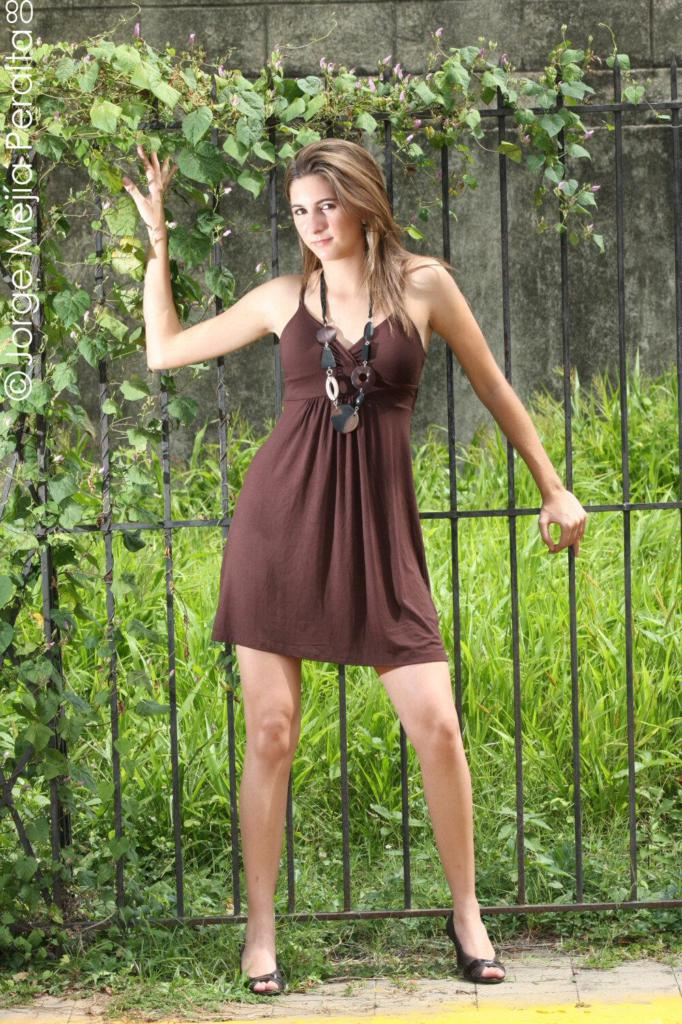

In [37]:
X['image']